In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch


def plot_feature_distributions(
    df,
    features,
    class_col="bbb_class",
    nonpenetrant_value=1,
    penetrant_value=0,
    bins_by_feature=None,
    ncols=3,
    figsize_per_panel=(5.5, 4.2),
    save_path=None,
):
    """
    Plot overlapping feature histograms for BBB non-penetrant and penetrant
    molecules.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the features and class labels.

    features : list[str]
        Features to plot.

    class_col : str
        Name of the binary class column.

    nonpenetrant_value
        Value corresponding to BBB non-penetrant molecules.

    penetrant_value
        Value corresponding to BBB penetrant molecules.

    bins_by_feature : dict, optional
        Dictionary specifying bins for individual features.

        Example:
            {
                "nHBDon": np.arange(-0.5, 7.5, 1),
                "MW": np.arange(0, 825, 10),
            }

    ncols : int
        Number of columns in the figure.

    save_path : str, optional
        File path for saving the figure.
    """

    bins_by_feature = bins_by_feature or {}

    # Include an extra axis for the legend.
    n_panels = len(features) + 1
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            figsize_per_panel[0] * ncols,
            figsize_per_panel[1] * nrows,
        ),
    )

    axes = np.asarray(axes).reshape(-1)

    nonpenetrant = df.loc[
        df[class_col] == nonpenetrant_value
    ]

    penetrant = df.loc[
        df[class_col] == penetrant_value
    ]

    for ax, feature in zip(axes, features):

        all_values = pd.to_numeric(
            df[feature],
            errors="coerce",
        ).dropna()

        np_values = pd.to_numeric(
            nonpenetrant[feature],
            errors="coerce",
        ).dropna()

        p_values = pd.to_numeric(
            penetrant[feature],
            errors="coerce",
        ).dropna()

        if feature in bins_by_feature:
            bins = bins_by_feature[feature]

        else:
            # Use integer-centered bins for low-cardinality integer features.
            is_integer_like = np.allclose(
                all_values,
                np.round(all_values),
            )

            if is_integer_like and all_values.nunique() <= 20:
                lower = int(np.floor(all_values.min()))
                upper = int(np.ceil(all_values.max()))

                bins = np.arange(
                    lower - 0.5,
                    upper + 1.5,
                    1,
                )

            else:
                bins = 35

        # Plot non-penetrant first so penetrant bars are overlaid.
          ax.hist(
            p_values,
            bins=bins,
            color="#009E2F",
            edgecolor="black",
            linewidth=1,
            alpha=0.95,
            label="BBB Penetrant",
        )

        ax.hist(
            np_values,
            bins=bins,
            color="skyblue",
            edgecolor="black",
            linewidth=1,
            alpha=0.85,
            label="BBB Non-Penetrant",
        )

      
        ax.set_xlabel(feature)
        ax.set_ylabel("Count")

    # Put the legend in the next available panel.
    legend_ax = axes[len(features)]
    legend_ax.axis("off")

    legend_handles = [
        Patch(
            facecolor="skyblue",
            edgecolor="black",
            label="BBB Non-Penetrant",
        ),
        Patch(
            facecolor="#009E2F",
            edgecolor="black",
            label="BBB Penetrant",
        ),
    ]

    legend_ax.legend(
        handles=legend_handles,
        loc="center",
        frameon=True,
        fontsize=18,
    )

    # Remove any remaining empty panels.
    for ax in axes[len(features) + 1:]:
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    return fig, axes

In [2]:
data = pd.read_csv("../datasets/druglike_b3db_labelled.csv")

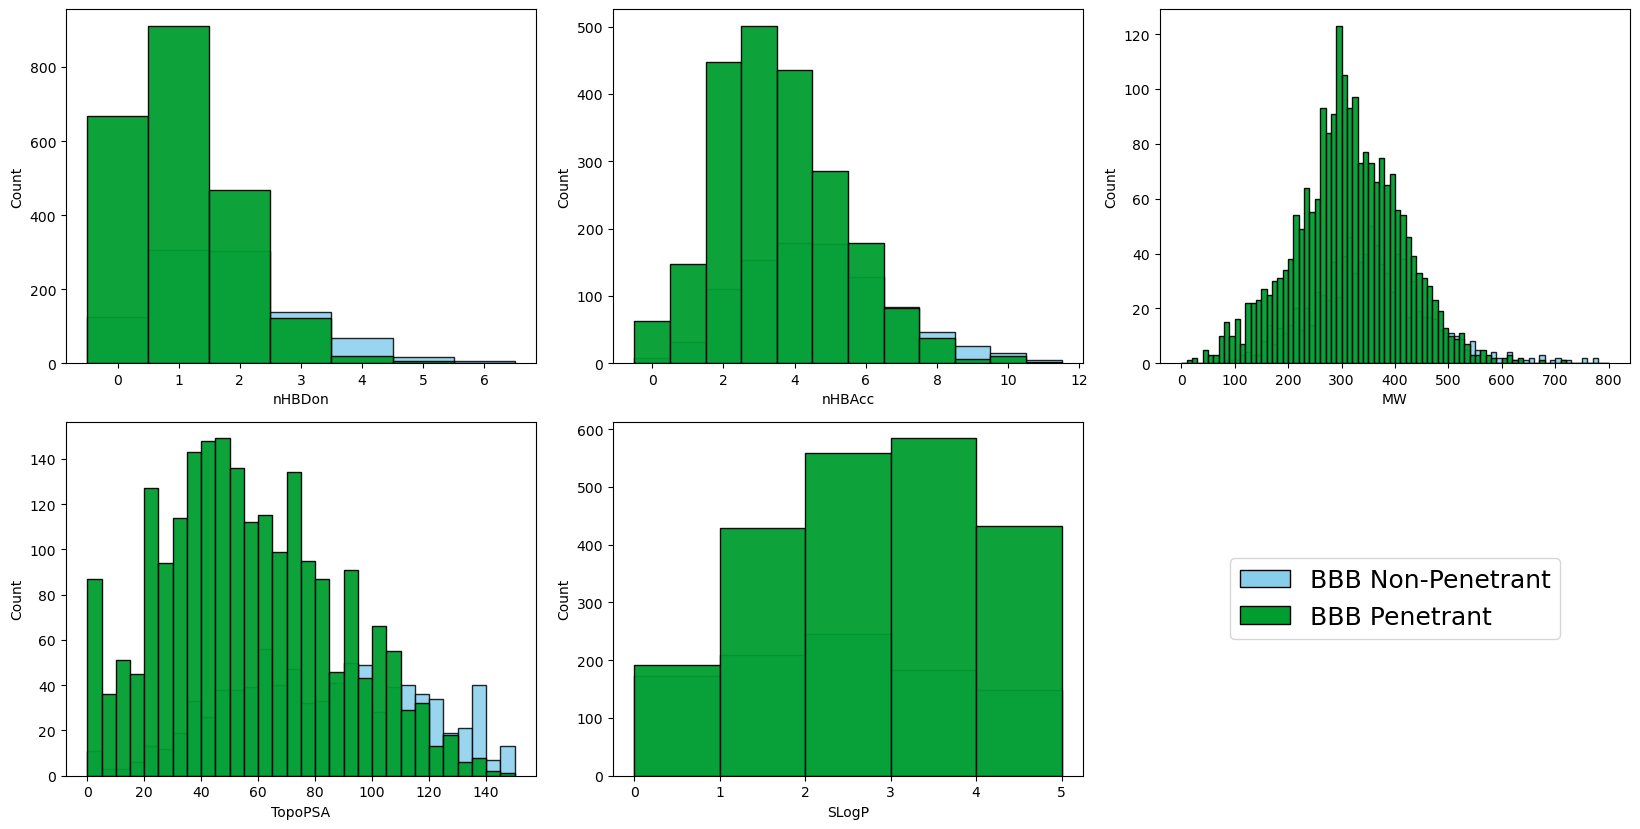

(<Figure size 1650x840 with 6 Axes>,
 array([<Axes: xlabel='nHBDon', ylabel='Count'>,
        <Axes: xlabel='nHBAcc', ylabel='Count'>,
        <Axes: xlabel='MW', ylabel='Count'>,
        <Axes: xlabel='TopoPSA', ylabel='Count'>,
        <Axes: xlabel='SLogP', ylabel='Count'>, <Axes: >], dtype=object))

In [4]:
features = [
    "nHBDon",
    "nHBAcc",
    "MW",
    "TopoPSA",
    "SLogP",
]

bins_by_feature = {
    "nHBDon": np.arange(-0.5, 7.5, 1),
    "nHBAcc": np.arange(-0.5, 12.5, 1),
    "MW": np.arange(0, 810, 10),
    "TopoPSA": np.arange(0, 155, 5),
    "SLogP": np.arange(0, 6, 1),
}

plot_feature_distributions(
    df=data,
    features=features,
    class_col="Class",
    nonpenetrant_value=1,
    penetrant_value=0,
    bins_by_feature=bins_by_feature,
    ncols=3,
    save_path="bbb_feature_distributions.png",
)